In [1]:
from totalsegmentator.python_api import totalsegmentator
import SimpleITK as sitk, nibabel as nib
import numpy as np, os

# ── 1. paths & label list ──────────────────────────────────────────────────────
dicom_dir = r"D:\Abdomen_CT_Bone_Mets\BMAB1_00000001"          # input CT folder
out_dir   = os.path.join(dicom_dir, "_seg_lung")              # where lung masks go
labels    = [
    "lung_upper_lobe_left",
    "lung_lower_lobe_left",
    "lung_upper_lobe_right",
    "lung_middle_lobe_right",
    "lung_lower_lobe_right"
]
combo_f   = os.path.join(out_dir, "lungs_combined.nii.gz")    # merged output

# ── 2. run TotalSegmentator (all 5 lung lobes, fast mode) ────────────────────
os.makedirs(out_dir, exist_ok=True)

totalsegmentator(
    dicom_dir, out_dir,
    roi_subset=labels,
    fast=True,                        # coarse‐res for speed; set False to refine
    nr_thr_resamp=1, nr_thr_saving=1, # avoid multiprocessing spawn quirks on Windows
    device="gpu"                      # or "cpu" if no GPU
)

# ── 3. load each lobar mask and merge them into one volume──────────────────────
mask_combined = None
for lab in labels:
    fpath = os.path.join(out_dir, f"{lab}.nii.gz")
    img   = nib.load(fpath)
    data  = img.get_fdata().astype(bool)

    if mask_combined is None:
        mask_combined = data
        affine, header = img.affine, img.header
    else:
        mask_combined |= data  # OR → any voxel in any lobe = 1

# ── 4. save the single “all‐lungs” mask as NIfTI────────────────────────────────
nib.save(nib.Nifti1Image(mask_combined.astype(np.uint8), affine, header), combo_f)
print("✅  Lung mask combined →", combo_f)


If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Using 'fast' option: resampling to lower resolution (3mm)
Generating rough segmentation for cropping...
Converting dicom to nifti...
  found image with shape (512, 512, 915)
Resampling...
  Resampled in 6.31s
Predicting...


100%|██████████| 8/8 [00:00<00:00, 30.00it/s]


  Predicted in 6.41s
Resampling...
Converting dicom to nifti...
  found image with shape (512, 512, 915)
  cropping from (512, 512, 915) to (392, 276, 242)
Resampling...
  Resampled in 0.56s
Predicting...


100%|██████████| 1/1 [00:00<00:00,  1.41it/s]


  Predicted in 6.79s
Resampling...
Saving segmentations...
  Saved in 6.81s
✅  Lung mask combined → D:\Abdomen_CT_Bone_Mets\BMAB1_00000001\_seg_lung\lungs_combined.nii.gz


In [17]:
import nibabel as nib
import SimpleITK as sitk
import numpy as np
import os

# ── 1. paths ──────────────────────────────────────────────────────────────
dicom_dir  = r"D:\Abdomen_CT_Bone_Mets\BMAB1_00000003"
combo_f    = os.path.join(dicom_dir, "_seg_lung", "lungs_combined.nii.gz")

# ── 2. Load the original CT series (for spacing and resampling) ────────────
reader = sitk.ImageSeriesReader()
reader.SetFileNames(reader.GetGDCMSeriesFileNames(dicom_dir))
ct_itk = reader.Execute()  # full CT in LPS

# Re-orient to RAS so that the mask and CT share the same coordinate convention
orienter = sitk.DICOMOrientImageFilter()
orienter.SetDesiredCoordinateOrientation("RAS")
ct_ras = orienter.Execute(ct_itk)

# Retrieve slice spacing (mm per axial slice)
z_spacing = ct_ras.GetSpacing()[-1]

# ── 3. Load the NIfTI lung mask and resample it into the CT grid ────────────
mask_itk = sitk.ReadImage(combo_f)  # mask in RAS, but potentially cropped
resampler = sitk.ResampleImageFilter()
resampler.SetReferenceImage(ct_ras)
resampler.SetInterpolator(sitk.sitkNearestNeighbor)
mask_on_ct_itk = resampler.Execute(mask_itk)

# Convert the resampled mask to a NumPy boolean array (shape = [Z, Y, X])
mask_np = sitk.GetArrayFromImage(mask_on_ct_itk).astype(bool)

# ── 4. Locate the diaphragm: the most inferior lung slice ────────────────────
#    (i.e., the highest index z where any lung voxel is present)
z_indices = np.where(mask_np.any(axis=(1, 2)))[0]
if z_indices.size == 0:
    raise RuntimeError("No lung voxels found → cannot locate diaphragm.")
diaphragm_idx = int(z_indices[-1])

# ── 5. Compute distance above diaphragm (cranial overscan) ───────────────────
#    Top slice index in this RAS-oriented grid:
top_slice_index    = mask_np.shape[0] - 1
distance_above_mm  = (top_slice_index - diaphragm_idx) * z_spacing

#    Subtract the 30 mm allowance
allowance_mm = 30.0
overscan_mm  = max(0.0, distance_above_mm - allowance_mm)

# ── 6. Report results ───────────────────────────────────────────────────────
print(f"Diaphragm slice (z index)    = {diaphragm_idx}")
print(f"Distance above diaphragm     = {distance_above_mm:.1f} mm")
if overscan_mm == 0:
    print("✅  No cranial overscan (within 30 mm allowance).")
else:
    print(f"⚠️   Cranial overscan         = {overscan_mm:.1f} mm "
          f"(≈ {overscan_mm / z_spacing:.1f} slices)")

Diaphragm slice (z index)    = 920
Distance above diaphragm     = 0.0 mm
✅  No cranial overscan (within 30 mm allowance).


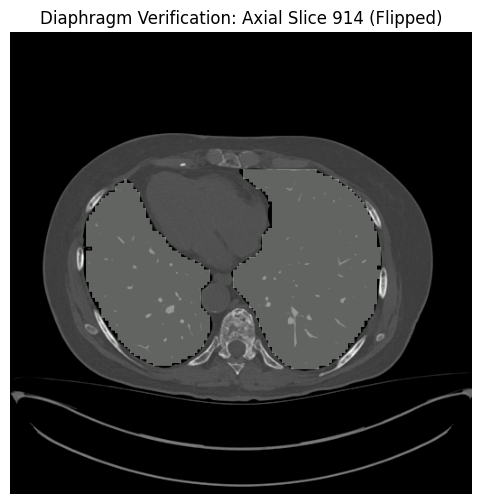

In [ ]:
# Add this at the very top to ensure inline plotting
%matplotlib inline

import SimpleITK as sitk
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import os

# ── 1. Paths & parameters ─────────────────────────────────────────────────────
dicom_dir    = r"D:\Abdomen_CT_Bone_Mets\BMAB1_00000003"
combo_f      = os.path.join(dicom_dir, "_seg_lung", "lungs_combined.nii.gz")

# ── 2. Load the combined lung mask (NIfTI) ─────────────────────────────────────
mask_np = nib.load(combo_f).get_fdata().astype(bool)   # shape = (Z, Y, X)

# ── 3. Load & re‐orient the CT series to RAS ──────────────────────────────────
reader = sitk.ImageSeriesReader()
reader.SetFileNames(reader.GetGDCMSeriesFileNames(dicom_dir))
ct_itk = reader.Execute()             # full CT in LPS

orienter = sitk.DICOMOrientImageFilter()
orienter.SetDesiredCoordinateOrientation("RAS")
ct_ras = orienter.Execute(ct_itk)

# ── 4. Resample mask to CT grid (if cropping was used) ─────────────────────────
mask_itk     = sitk.ReadImage(combo_f)
resampler    = sitk.ResampleImageFilter()
resampler.SetReferenceImage(ct_ras)
resampler.SetInterpolator(sitk.sitkNearestNeighbor)
mask_on_ct_itk = resampler.Execute(mask_itk)
mask_np = sitk.GetArrayFromImage(mask_on_ct_itk).astype(bool)  # (Z, Y, X)

# ── 5. Determine diaphragm slice (most inferior lung slice) ────────────────────
diaphragm_idx = int(np.where(mask_np.any(axis=(1, 2)))[0][-1])

# ── 6. Overlay that slice (flipped so diaphragm is at bottom) ─────────────────
def hu_window(arr, level=400, width=2000):
    lo, hi = level - width/2, level + width/2
    arr = np.clip(arr, lo, hi)
    return ((arr - lo) / (hi - lo) * 255).astype(np.uint8)

ct_np = sitk.GetArrayFromImage(ct_ras)  # (Z, Y, X) in RAS

plt.figure(figsize=(6, 6))
plt.imshow(hu_window(ct_np[diaphragm_idx]), cmap="gray", origin="lower")
plt.imshow(
    np.ma.masked_where(~mask_np[diaphragm_idx], mask_np[diaphragm_idx]),
    alpha=0.4, origin="lower", cmap="Greens"
)
plt.title(f"Diaphragm Verification: Axial Slice {diaphragm_idx} (Flipped)")
plt.axis("off")
plt.show()